# Chapter 3 MNIST Dataset Work
Barclay Barnes


We will be using the MNIST Dataset to train a model based on handwriting samples and will in the end detect what number someone has written by viewing a 28x28 image.


In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)


SKLearn.Datasets contains 3 different primary functions


*   Fetch_OpenML(): to download real life datasets
*   Load_*: To load small toy datasets bundled with Scikit-Learn to avoid downloading over internet
*   Make_*: To generate fake datasets which is useful for tests.

These generated datasets are returned in the fashion of (X, y) tuple containing the input data and targets.





# Using Fetch_OpenML()

Fetch function returns inputs as a Pandas DataFrame and the labels as a Pandas series if the data isn't sparce. Since the MNIST dataset contains images this isn't ideal so we will set as_Frame to false above.

# Image Info

There are 70,000 images and each image has 784 features. This is because each image is 28x28 pixels, and each feature represents a pixels intensity from 0 to 255 or white to black. We'll show a 5 as an example.


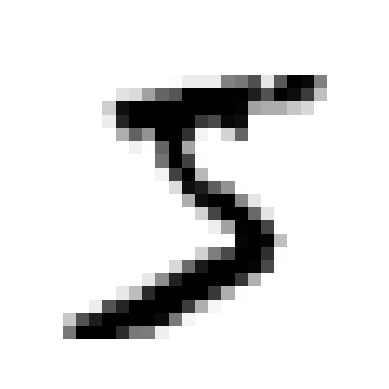

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap='binary')
  plt.axis("off")

some_digit = mnist.data[0]
plot_digit(some_digit)

plt.show()

Binary Classifier

We will simplify the scope of problem and only try to identify one single digit that digit being 5. This is an example of a binary classifier that is capable of distinguishing between just two classes, 5 and non-5.

In [ ]:
X, y = mnist.data, mnist.target
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:] #Test Set
y_train_5 = (y_train == '5') # True for all 5s, False for other digits
y_test_5 = (y_test == '5')

Here we are splitting the Dataset into 60,000 entries for training and 10,000 for testing

Lets now pick a classifier and train it. We start with Stochastic Gradient Descent which we spoke about in the 2nd week of notes review. This method is also suited well for online learning.

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([some_digit])

array([ True])

# Cross Validation

Cross-validation gives us a better estimate of how the model performs on unseen data by rotating through different subsets of it. Accuracy measures the fraction of correct predictions. It is important to note this can be misleading if classes are imbalanced

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

# Controlling Cross Validation and Implementation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is
                                      # not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
  clone_clf = clone(sgd_clf)
  X_train_folds = X_train[train_index]
  y_train_folds = y_train_5[train_index]
  X_test_fold = X_train[test_index]
  y_test_fold = y_train_5[test_index]

  clone_clf.fit(X_train_folds, y_train_folds)
  y_pred = clone_clf.predict(X_test_fold)
  n_correct = sum(y_pred == y_test_fold)
  print(n_correct / len(y_pred)) # prints 0.95035, 0.96035, and 0.9604 '

  # StratisifiedKFold class performs stratified sampling to produce folds that contain a representative ratio of each class

0.95035
0.96035
0.9604


# Confusion Matrices

A confusion matrix shows how many examples were correctly or incorrectly classified for each class. The provides a better understanding than accuracy alone.

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)


[[53892   687]
 [ 1891  3530]]


$Precision = \frac{TP}{TP+FP}$




# Precision, Recall, and F1 Score




In [ ]:
from sklearn.metrics import precision_score
precision_score(y_train_5, y_train_pred)


0.8370879772350012

* Precision tells you what fraction of predicted “5s” were actually 5s.

In [ ]:
from sklearn.metrics import recall_score
recall_score(y_train_5, y_train_pred)

0.6511713705958311

* Recall tells you what fraction of actual 5s were detected.

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

* F1 Score balances precision and recall into a single metric.

# Precision Recall Trade-Off

Essentially the Precision Recall Trade-Off is as follows as one increases strictness of acceptance in the model it improves precision but reduces recall. Allowing the model to be more lenient improves the recall but lowers the precision. Improving one hurts another so that leads you to ensuring there is a good balance based on the scope and goal of your model.

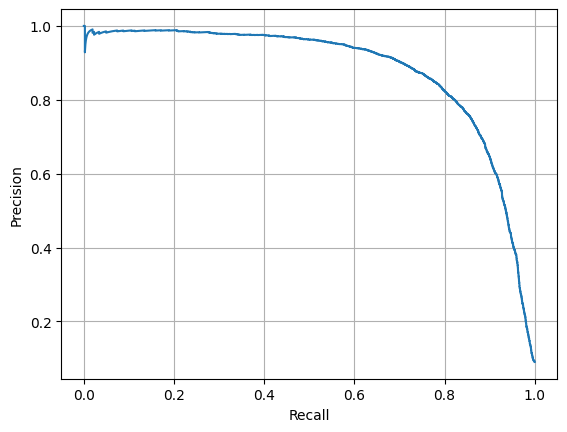

In [ ]:
from sklearn.metrics import precision_recall_curve

y_scores = sgd_clf.decision_function(X_train)
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# This shows the trade off between precision and recall

# Precision Plot and Recall

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [ ]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

# Plot Precision and Recall
Plot Precision and Recall as functions of the threshold 3000.

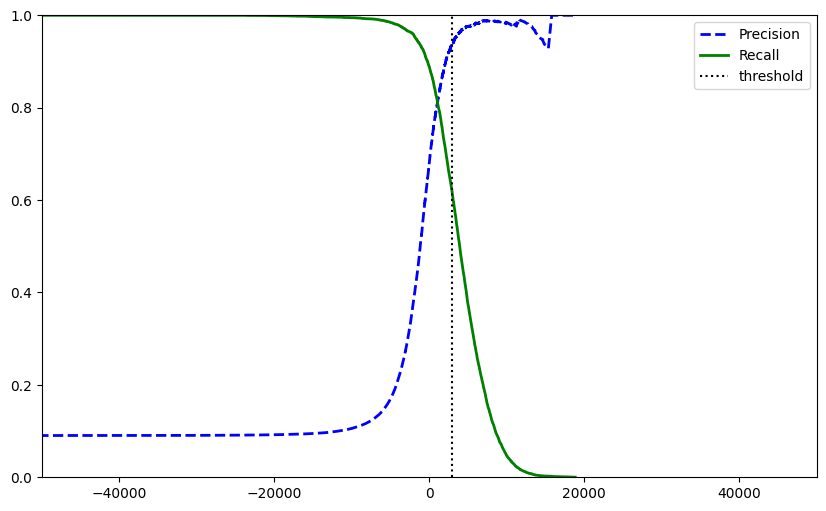

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.ylim([0,1.0])
plt.xlim([-50000, 50000])
plt.show()

Conduct same example with threshold of 5000

In [ ]:
threshold = 5000
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.ylim([0,1.0])
plt.xlim([-50000, 50000])
plt.show()

NameError: name 'plt' is not defined

# ROC Curve

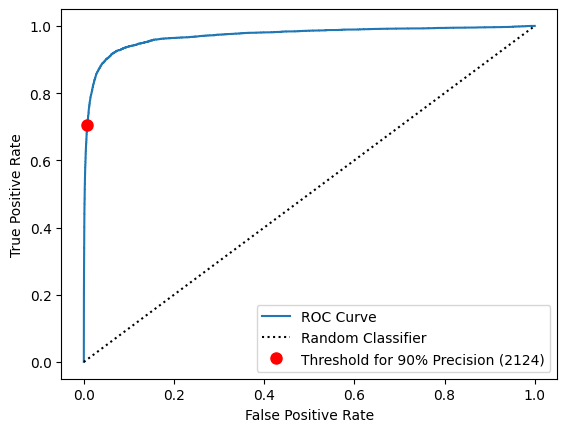

np.float64(0.9709618248430906)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

y_scores = sgd_clf.decision_function(X_train)

fpr, tpr, roc_thresholds = roc_curve(y_train_5, y_scores)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], "k:", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")


threshold_for_90_precision_idx = np.argmax(precisions >= 0.90)
threshold_for_90_precision = thresholds[threshold_for_90_precision_idx]
closest_roc_threshold_idx = np.argmin(np.abs(roc_thresholds - threshold_for_90_precision))
plt.plot(fpr[closest_roc_threshold_idx], tpr[closest_roc_threshold_idx], "ro", markersize=8, label=f"Threshold for 90% Precision ({threshold_for_90_precision:.0f})")

plt.legend()
plt.show()

roc_auc_score(y_train_5, y_scores)

* **ROC Curve** plots the true positive rate vs false positive rate at various thresholds
* **AUC** is the area under the ROC curve. Singular number that summarizes performance across thresholds. Perfect classifier has a AUC of 1.



# Random Forest

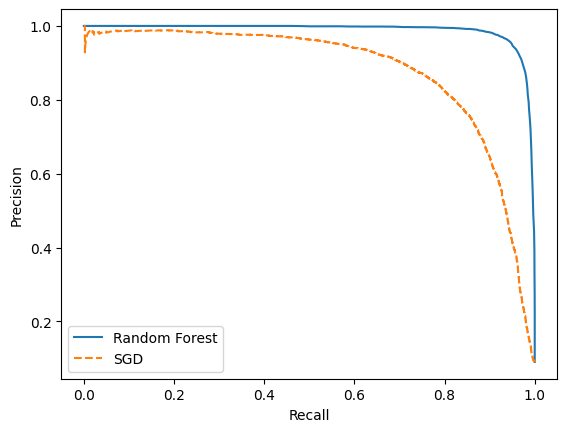

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(
    forest_clf, X_train, y_train_5, cv=3, method="predict_proba"
)

y_scores_forest = y_probas_forest[:, 1]

precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot(recalls_forest, precisions_forest, label="Random Forest")
plt.plot(recalls, precisions, "--", label="SGD")
plt.legend()
plt.show()

Random forests are non-linear models that often perform better than linear classifiers when using complex data. Plotting their curves side-by-side helps compare the model's behavior

# Forest F1 and AUC

In [ ]:
y_train_pred_forest = y_scores_forest >= 0.5

f1_score(y_train_5, y_train_pred_forest), roc_auc_score(y_train_5, y_scores_forest)

(0.9274509803921569, np.float64(0.9983436731328145))

We're measuring F1 and AUC for the random forest. This along with the precision-recall visualizer assists in benchmarking performance against stochastic gradient descent

# Multiclass Classification

In multiclass classification, the model predicts one label out of many posssible classes. In this case it predicts digits 0-9. SGD Classifier allows for this by internally training multiple binary classifiers using a one vs the rest stategy where each digit is compared against all others in the set.

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

sgd_clf.fit(X_train, y_train)
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:2000], y_train[:2000])

# Using 3-fold cross validation to estimate classification accuracy over dataset

cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

# Feature Scaling

Standardizing features transforms the pixel values so they have a mean of 0 and STD of 1. Many linear models, including SGD, perform better when the input features are on a similar scale because large feature values can end up dominating gradient updates and slower convergence.

# Error Analysis



In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

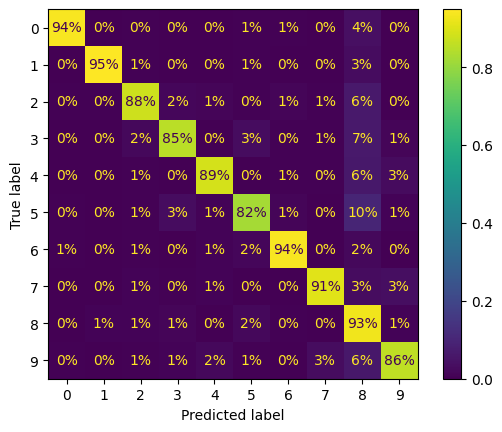

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

# Generate cross-validated predictions using the scaled training data.
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

# Display a normalized confusion matrix to show where classifier makes errors
# Normalization shows percentages not raw counts
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, normalize="true", values_format=".0%"
)
plt.show()

A normalized confusion matrix highlights the systematic errors, such as certain digits being confused with others (for example, 3s misclassified as 5s). This analysis helps identify weaknesses in the model and suggests where more data or better features may help.

# Multilabel Classification

# Creating Multilabel Targets

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)

y_multilabel = np.c_[y_train_large, y_train_odd]

Unlike multiclass classification, where each image belongs to one single digit,
multilabel classification allows each image to belong to multiple categories at once, such as being both large and odd.

# Training KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

# Predict multilabel outputs for a sample digit.
knn_clf.predict([some_digit])

array([[0, 5]], dtype=int8)

# Multi Label Evaluation

In [ ]:
# Multilabel F1 Score
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

f1_score(y_multilabel, y_train_knn_pred, average="macro")

The macro F1 score evaluates how well the model performs across each label independently. This ensures that the performance on one label does not dominate the overall score and provides an overall balanced view of multilabel prediction quality.

# Conclusion and Final Notes

In this Lab, I explored multiple classifications techniques using the MNIST dataset. This began with binary classification and extended all the way to multiclass and multilabel learning.

We also evaluated the performance of models using accuracy, precision, recall, F1 score, confusion matrices, and ROC precision-recall curves, demonstrating how different metrics can reveal different aspects of behavior for a classifier.

By comparing linear models, ensemble methods, and instance based learning methods while applying minor feature scaling and error analysis, I showed the importance of preprocessing and model choice on performance, reinforcing the importance of thoughtful evaluation and iteratively improving your workflows.

